In [79]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import find_peaks

plt.style.use(r"C:\UserData\z003zh2j\OneDrive - Siemens AG\Documents\plot\matlab.mplstyle")

UR = np.genfromtxt(r"S:\1.FILE\ern\kolben-cdr.csv", delimiter=',', skip_header=0)

t = UR[: , 0]/1e6
a = UR[: , 1]/1e3
b = UR[: , 2]/1e3
r = UR[: , 3]/1e3

sin A - KO!, DC offset > 5% Amp
sin B - KO!, DC offset > 5% Amp
KO! amplituda
mean fázového posunu 90.14707071765667


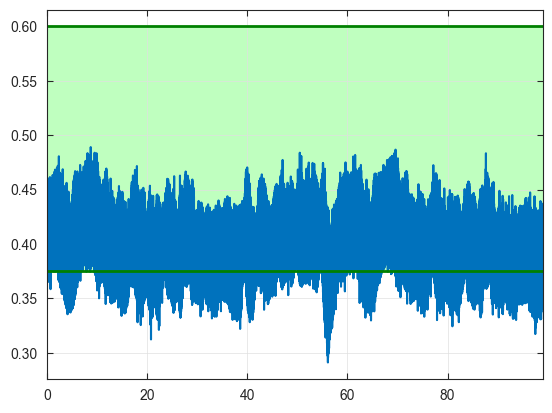

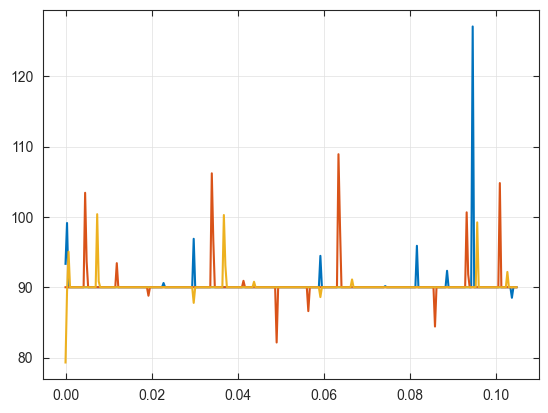

In [105]:
vysledek = ""
def test(signal):
    global vysledek

    if np.mean(signal) >= (0.05 * np.max(signal)):
        vysledek=("KO!, DC offset > 5% Amp")
    else:
        vysledek=("OK, DC offset OK")

test(a)
print("sin A -", vysledek)
test(b)
print("sin B -", vysledek)

polomer = np.sqrt(a**2+b**2)

#print(np.min(polomer),np.max(polomer))

if np.min(polomer) <= 0.75/2 or np.max(polomer) >= 1.2/2:
    print("KO! amplituda")
else:
    print("OK? amplituda")
# pridej tuhle podminku do testovaci funkce

da = np.gradient(a)
db = np.gradient(b)

# Spočítáme úhly pro a a b samostatně s korekcí na kvadrant
uhel_a = np.arcsin(a / polomer)
uhel_b = np.arcsin(b / polomer)

# Pokud signál klesá (derivace < 0), musíme úhel zrcadlit kolem pi/2
uhel_a = np.where(da < 0, np.pi - uhel_a, uhel_a)
uhel_b = np.where(db < 0, np.pi - uhel_b, uhel_b)

# Pokud se dostaneme do záporných hodnot, zarovnáme do rozsahu 0 až 2*pi
uhel_a = np.mod(uhel_a, 2 * np.pi)
uhel_b = np.mod(uhel_b, 2 * np.pi)

# Výsledný fázový rozdíl
fi = uhel_a - uhel_b

# Korekce, aby byl rozdíl vždy v rozumném rozsahu a dělal rovnou čáru
fi = (fi + np.pi) % (2 * np.pi) - np.pi
fi = abs(180/np.pi*fi)
print("mean fázového posunu",np.mean(fi))

plt.figure()
plt.plot(t,polomer)
plt.hlines(0.75/2,0,t[-1]//5,color = 'g',lw = 2)
plt.hlines(1.2/2,0,t[-1]//5,color = 'g', lw = 2)
plt.xlim(0,t[-1]//5)
import matplotlib.patches as patches
obdelnik = patches.Rectangle((0, 0.75/2),t[-1]//5 ,1.2/2-0.75/2 , edgecolor='none', facecolor='lime', alpha=0.25, linewidth=1)
os = plt.gca()
os.add_patch(obdelnik)
plt.show()

plt.figure()
plt.plot(t[0:300],fi[0:300])
plt.plot(t[0:300],fi[3000:3300])
plt.plot(t[0:300],fi[30000:30300])
#plt.xlim(0,0.1)
plt.show()

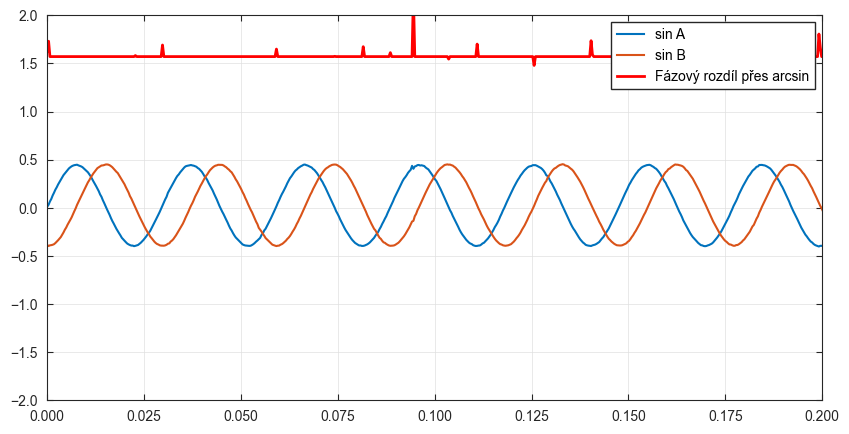

In [82]:
da = np.gradient(a)
db = np.gradient(b)

# Spočítáme úhly pro y a y2 samostatně s korekcí na kvadrant
uhel_a = np.arcsin(a / polomer)
uhel_b = np.arcsin(b / polomer)

# Pokud signál klesá (derivace < 0), musíme úhel zrcadlit kolem pi/2
uhel_a = np.where(da < 0, np.pi - uhel_a, uhel_a)
uhel_b = np.where(db < 0, np.pi - uhel_b, uhel_b)

# Pokud se dostaneme do záporných hodnot, zarovnáme do rozsahu 0 až 2*pi
uhel_a = np.mod(uhel_a, 2 * np.pi)
uhel_b = np.mod(uhel_b, 2 * np.pi)

# Výsledný fázový rozdíl
fi = uhel_a - uhel_b

# Korekce, aby byl rozdíl vždy v rozumném rozsahu a dělal rovnou čáru
fi = (fi + np.pi) % (2 * np.pi) - np.pi

# Vykreslení
plt.figure(figsize=(10, 5))
plt.plot(t, a, label='sin A')
plt.plot(t, b, label='sin B')
plt.plot(t, np.abs(fi), label='Fázový rozdíl přes arcsin', color='red', linewidth=2)
plt.xlim(0, 0.2)
plt.ylim(-2, 2)
plt.legend()
plt.grid(True)
plt.show()

In [10]:
try:
  def pnej(seznam):
    points = find_peaks(seznam, distance=100000)
    i = 0
    N = []
    for n in points[0]:
        if seznam[n] > 0:
            if i <= 0:
                i += 1
                N.append(n)
    indexy = N[0]
    return indexy                
except IndexError:
  R, RR, RRR = 50,100,100

R = t[pnej(r)]

def timel(leng,okno,jaky):
    if jaky == "R":
        jaky = R

    N1 = np.linspace(jaky-(-1 * ((leng-1) /2)) * okno , jaky-((leng-1) /2)* okno,leng)
    N2 = np.linspace(-1 * ((leng-1) /2) * okno , ((leng-1) /2) * okno,leng)
    N1 = N1.tolist()
    N1.sort()
    N2 = N2.tolist()
    N2 = ["%.2f" % member for member in N2]

    return(N1,N2)

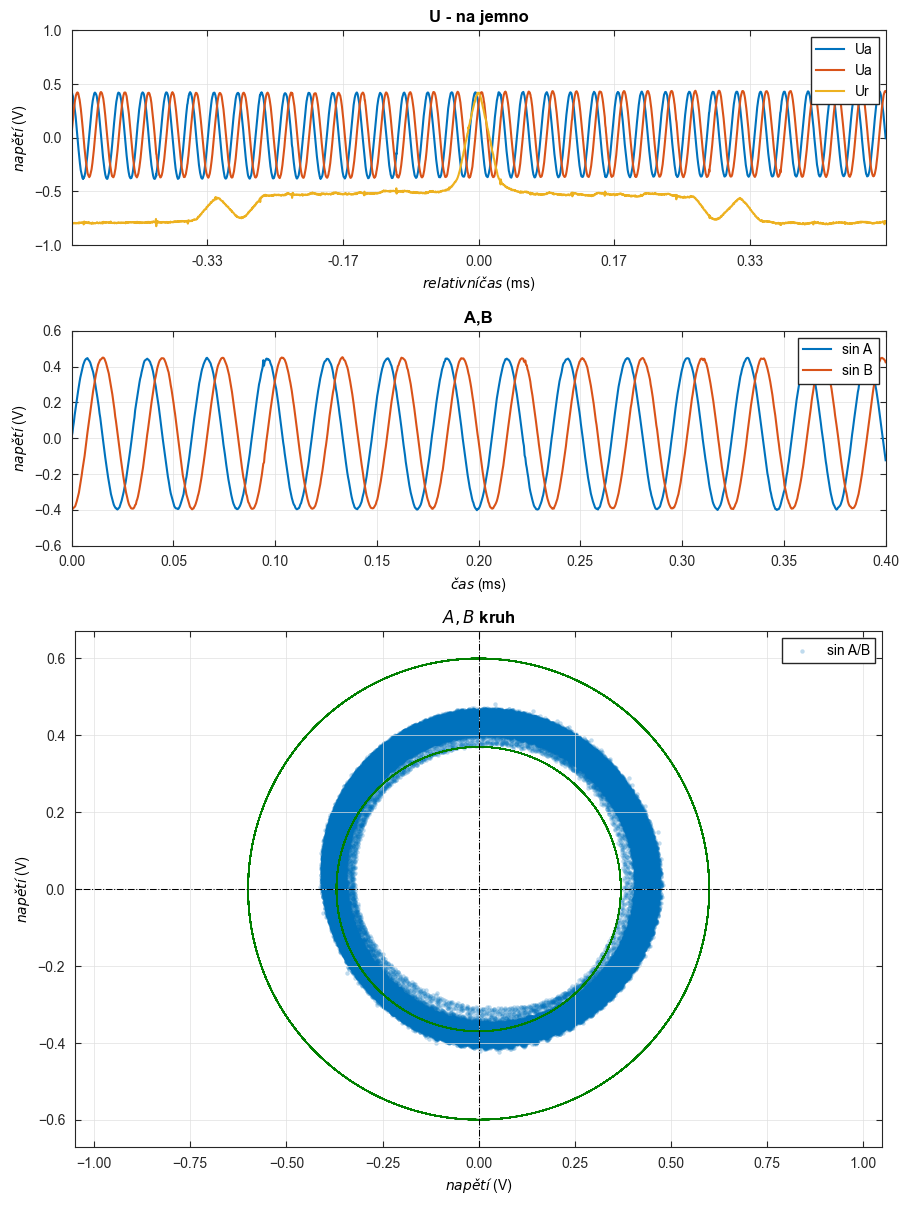

In [11]:
fig = plt.figure(figsize=(10.5, 14.5))

# Vytvoření mřížky (4 řádků, 1 sloupec)
gs = fig.add_gridspec(4, 1, hspace=0.4, wspace=0.3)

# 1. Horní graf - zabere 1. řádek (index 0)
ax1 = fig.add_subplot(gs[0, 0])
N1 , N2 = timel(5,0.5/3,"R")
ax1.set_xticks(N1) 
ax1.set_xticklabels(N2)
ax1.plot(t, a, label="Ua")
ax1.plot(t, b, label="Ua")
ax1.plot(t, r, label="Ur")
ax1.set_xlim(R-0.5, R+0.5)
ax1.set_ylim(-1, 1)
ax1.set_title('U - na jemno')
ax1.legend(loc='upper right')
ax1.set_xlabel("$relativní čas$ (ms)")
ax1.set_ylabel("$napětí$ (V)")

# 2. Prostřední graf - zabere 2. řádek (index 1)
ax2 = fig.add_subplot(gs[1, 0])
ax2.set_xlim(0,0.4)
ax2.set_ylim(-0.6, 0.6)
ax2.plot(t, a, label="sin A")
ax2.plot(t, b, label="sin B")
ax2.set_title("A,B")
ax2.legend(loc='upper right')
ax2.set_xlabel("$čas$ (ms)")
ax2.set_ylabel("$napětí$ (V)")

# 3. Velký spodní graf - zabere zbývající 3 řádky (indexy 2 až 4)
# V Pythonu se to zapisuje pomocí řezu (slice) [2:5] neboli od indexu 2 včetně do 5 (vyjma)
ax3 = fig.add_subplot(gs[2:4, 0])
x = np.linspace(0,1000,10000)
y = 0.6 *np.sin(1*x+0)+0
yy = 0.6 *np.sin(1*x+np.pi/2)+0
w = 0.37 *np.sin(1*x+0)+0
ww = 0.37 *np.sin(1*x+np.pi/2)+0
ax3.plot(y, yy, lw=0.75, color='g')
ax3.plot(w, ww, lw=0.75, color='g')
ax3.scatter(a[0:len(a)//6], b[0:len(b)//6], linewidths=0.1, marker=".", alpha=0.25, label="sin A/B")

#ax3.set_xlim(-0.67, 0.67)
ax3.set_xlim(-1.05, 1.05)
ax3.set_ylim(-0.67, 0.67)
ax3.vlines(0, -0.67, 0.67, color='k', linestyles='-.', lw=0.75)
ax3.hlines(0, -1.2, 1.2, color='k', linestyles='-.', lw=0.75)
ax3.set_title("$A,B$ kruh")
ax3.legend(loc='upper right')
ax3.set_xlabel("$napětí$ (V)")
ax3.set_ylabel("$napětí$ (V)")
ax3.set_aspect('equal', adjustable='box')

# # Zobrazení grafu
plt.show()
